# What Is QSAR?

This notebook accompanies the QSAR tutorial chapter: **What Is QSAR?**.

## Goal

This chapter introduces the basic QSAR idea:

**chemical structure → numerical features → model → predicted endpoint**

Here we simply load the example dataset and inspect the chemical structures and endpoint values.

In [1]:
from pathlib import Path
import pandas as pd

def find_example_dataset():
    candidates = [
        Path("../data/example_qsar_dataset.csv"),
        Path("data/example_qsar_dataset.csv"),
        Path("../../data/example_qsar_dataset.csv"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Could not find example_qsar_dataset.csv. "
        "Make sure the notebook is inside a chapter folder next to the shared data folder."
    )

data_path = find_example_dataset()
df = pd.read_csv(data_path)
df.head()

,CompoundID,Name,SMILES,Activity,Class
0,Cmpd001,Methane,C,0.709,0.0
1,Cmpd002,Ethane,CC,0.931,0.0
2,Cmpd003,Propane,CCC,1.717,0.0
3,Cmpd004,Butane,CCCC,2.215,1.0
4,Cmpd005,Pentane,CCCCC,2.159,1.0


In [2]:
print("Number of compounds:", len(df))
print("Columns:", df.columns.tolist())

display(df[["CompoundID", "Name", "SMILES", "Activity", "Class"]].head(10))

Number of compounds: 41
Columns: ['CompoundID', 'Name', 'SMILES', 'Activity', 'Class']


,CompoundID,Name,SMILES,Activity,Class
0,Cmpd001,Methane,C,0.709,0.0
1,Cmpd002,Ethane,CC,0.931,0.0
2,Cmpd003,Propane,CCC,1.717,0.0
3,Cmpd004,Butane,CCCC,2.215,1.0
4,Cmpd005,Pentane,CCCCC,2.159,1.0
5,Cmpd006,Hexane,CCCCCC,2.740,1.0
6,Cmpd007,Ethanol,CCO,0.650,0.0
7,Cmpd008,Propanol,CCCO,1.034,0.0
8,Cmpd009,Isopropanol,CC(C)O,1.087,0.0
9,Cmpd010,Acetic acid,CC(=O)O,0.539,0.0


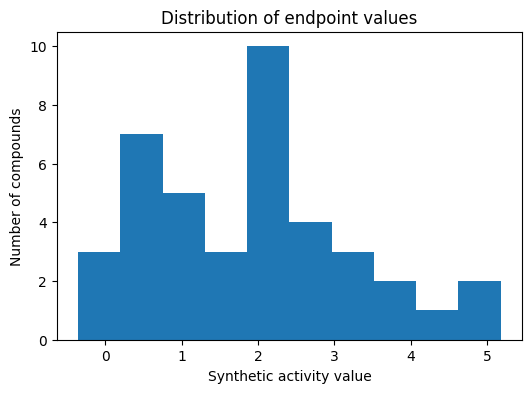

In [3]:
import matplotlib.pyplot as plt

activity = pd.to_numeric(df["Activity"], errors="coerce").dropna()

plt.figure(figsize=(6, 4))
plt.hist(activity, bins=10)
plt.xlabel("Synthetic activity value")
plt.ylabel("Number of compounds")
plt.title("Distribution of endpoint values")
plt.show()

## Discussion

- The `SMILES` column represents molecular structure.
- The `Activity` column is the continuous endpoint for regression examples.
- The `Class` column is a binary endpoint for classification examples.